<a href="https://colab.research.google.com/github/aansheeagrwal/python-training/blob/main/Generative_Adversial_Network(GANs).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Generative Adversarial Network (GANs):-

They are type of deep learning that is used for generate new, synthetic data that is similar to real data(just like image,music,text,video). it has two neural networks:


1.   Generators
2.   Discriminator

Generator:- Generator is basically used to create fake data that is so realistic that it can full the discriminator into thinking real.

Discriminator:- Discriminator is to tell us the difference between real or fake.

###Workflow of GANs:-
* Input random noise into the generator
* Generator produce fake image
* Fake image and real image or passed to the discriminator
* Discriminator try to guess which one is the real
* Generator update to improve how real the fake looks
* Discriminator to update better detect better fake
* The competition continues untill the fake image become realistic in a that the discriminator can not till the difference.

Random noise(z) -> Generator -> Fake image -> Generate data(eg:image) that looks real

###Workflow of Generator:-
* Input
* Processing: Pass the input data through a series of layers (Dense,Conv Transpose, Batch Norms)
* Output: Image generated





In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, BatchNormalization, LeakyReLU, Conv2DTranspose,Conv2D,Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [35]:
#load dataset --
(X_train,_),(X_test,_)=mnist.load_data()
X_train=(X_train -127.5)/127.5 #normalize[-1,1]
X_train=np.expand_dims(X_train,axis=3)
print(X_train.shape)

datasize = 60000
batch_size = 128
latent_dim = 100

def generator(num_dim = 100):
  # Fully Connected layers
  model = Sequential()
  model.add(Dense(128*7*7,input_dim = num_dim))
  model.add(BatchNormalization())
  model.add(LeakyReLU(alpha=0.2))
  model.add(Reshape((7,7,128)))

  #Sample1 --
  model.add(Conv2DTranspose(128,kernel_size=4,strides=2,padding="same"))
  model.add(BatchNormalization())
  model.add(LeakyReLU(alpha=0.2))

  #Sample2 --
  model.add(Conv2DTranspose(128,kernel_size=4,strides=2,padding="same"))
  model.add(BatchNormalization())
  model.add(LeakyReLU(alpha=0.2))

  #sample3 --
  model.add(Conv2DTranspose(1,kernel_size=3,strides=1,activation = "tanh",padding="same"))

  return model

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28, 1)


In [36]:
Generators = generator()
Generators.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 14, 14, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 28, 28, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 28, 28, 1)      │         1,153 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185,281 (4.52 MB)

 Trainable params: 1,172,225 (4.47 MB)

 Non-trainable params: 13,056 (51.00 KB)

In [24]:
Generators.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))

In [25]:
import numpy as np
import matplotlib.pyplot as plt
input=np.random.normal(0,1,(1,100))

output = Generators.predict(input)
output1 = (output+1)/2.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


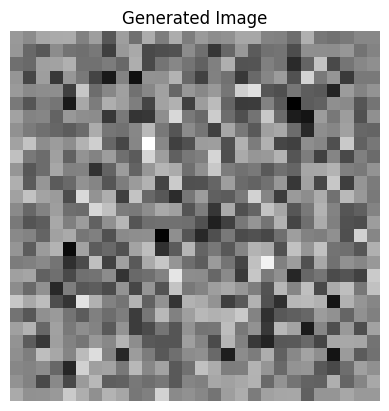

In [26]:
plt.imshow(output1[0,:,:,0],cmap='gray')
plt.title("Generated Image")
plt.axis("off")
plt.show()

In [27]:
# Discriminators --
def Discriminator():
  model = Sequential()
  model.add(Conv2D(64,kernel_size=3,strides=2,input_shape=(28,28,1),padding="same"))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Conv2D(128,kernel_size=3,strides=2,padding="same"))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Flatten())
  model.add(Dense(1,activation="sigmoid"))

  return model

In [28]:
Discriminator = Discriminator()
Discriminator.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,769 (315.50 KB)

 Trainable params: 80,769 (315.50 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
Discriminator.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))

In [32]:
import numpy as np
import matplotlib.pyplot as plt
input=np.random.normal(0,1,(1,100))

output = Generators.predict(input)
# output1 = (output+1)/2.0 # This line is not needed here as Discriminator expects raw output

# Use the output of the Generator as input to the Discriminator
discriminator_output = Discriminator.predict(output)

print("Discriminator output:", discriminator_output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Discriminator output: [[0.49987578]]


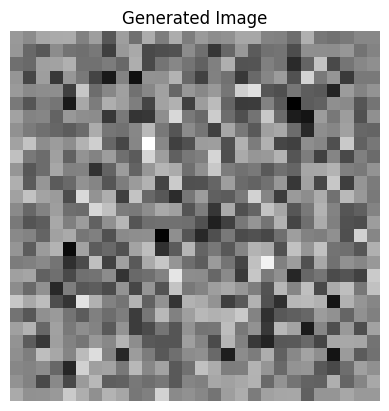

In [34]:
plt.imshow(output1[0,:,:,0],cmap='gray')
plt.title("Generated Image")
plt.axis("off")
plt.show()